In [ ]:
# Install required packages
!pip install kaggle scikit-learn pandas numpy matplotlib seaborn joblib nltk -q

import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.utils import resample

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

print('✅ All dependencies loaded successfully!')

✅ All dependencies loaded successfully!


In [ ]:
# ── Load & Prepare Dataset ─────────────
USE_REAL_DATASET = True  # Set to True when you have the CSV files

if USE_REAL_DATASET:
    fake_df = pd.read_csv('Fake.csv', engine='python')
    true_df = pd.read_csv('True.csv', engine='python', on_bad_lines='skip')

    # Combine title + text for richer features
    fake_df['text'] = fake_df['title'].fillna('') + ' ' + fake_df['text'].fillna('')
    true_df['text'] = true_df['title'].fillna('') + ' ' + true_df['text'].fillna('')

    fake_df['label'] = 0  # 0 = FAKE
    true_df['label'] = 1  # 1 = REAL

    df_raw = pd.concat([fake_df[['text', 'label']], true_df[['text', 'label']]], ignore_index=True)

    print(f'Real ISOT Dataset loaded!')
    print(f'Shape: {df_raw.shape}')
    print(df_raw['label'].value_counts())
else:
    print('Using synthetic dataset. Set USE_REAL_DATASET=True to use ISOT.')

Real ISOT Dataset loaded!
Shape: (44898, 2)
label
0    23481
1    21417
Name: count, dtype: int64


In [ ]:
# --------Text Cleaning Function------
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    """Robust text cleaning pipeline."""
    if not isinstance(text, str):
        return ''
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove Reuters / wire service headers (common in ISOT dataset)
    text = re.sub(r'^.*?\(reuters\)\s*[-–]?\s*', '', text)
    # Remove special characters (keep letters, spaces, basic punctuation)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print('Cleaning text... (may take a minute)')
df = df_raw.copy()
df['text'] = df['text'].apply(clean_text)

# Drop empty rows
df = df[df['text'].str.len() > 20].reset_index(drop=True)

# Drop duplicate articles
df = df.drop_duplicates(subset='text').reset_index(drop=True)

print(f'After cleaning: {df.shape}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'\nSample cleaned text:')
print(df['text'].iloc[0][:300])

Cleaning text... (may take a minute)
After cleaning: (38824, 2)

Label distribution:
label
1    20924
0    17900
Name: count, dtype: int64

Sample cleaned text:
donald trump sends embarrassing new year eve message disturbing donald trump wish americans happy new year leave instead give shout enemies haters dishonest fake news media former reality show star one job country rapidly grows stronger smarter want wish friends supporters enemies haters even dishon


Original counts: {1: np.int64(20924), 0: np.int64(17900)}
Balancing to 17900 samples per class...
Balanced counts: {0: np.int64(17900), 1: np.int64(17900)}


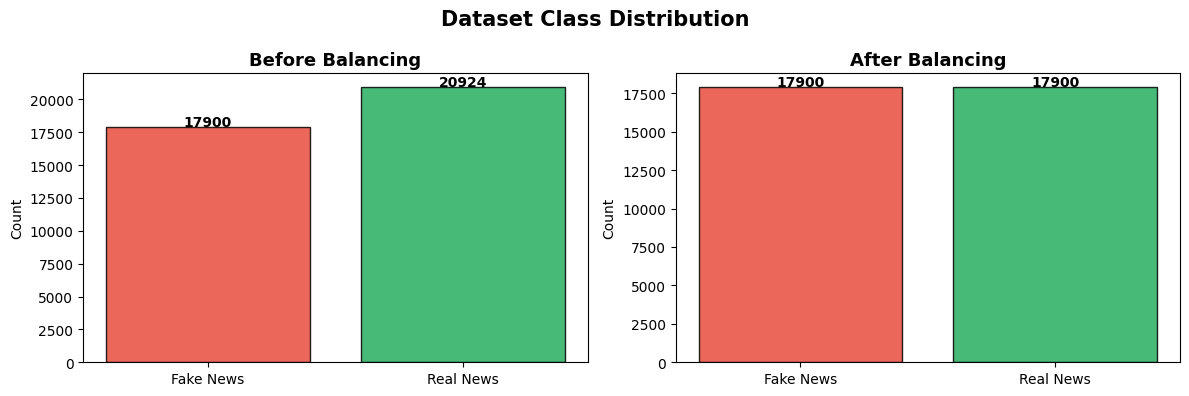

✅ Dataset balanced!


In [ ]:
#-----Balance Dataset
def balance_dataset(df, label_col='label', random_state=42):
    """Undersample majority class to create perfectly balanced dataset."""
    counts = df[label_col].value_counts()
    min_count = counts.min()
    print(f'Original counts: {dict(counts)}')
    print(f'Balancing to {min_count} samples per class...')

    balanced_parts = []
    for label in df[label_col].unique():
        subset = df[df[label_col] == label]
        balanced_parts.append(
            resample(subset, n_samples=min_count, replace=False, random_state=random_state)
        )

    balanced_df = pd.concat(balanced_parts).reset_index(drop=True)
    print(f'Balanced counts: {dict(balanced_df[label_col].value_counts())}')
    return balanced_df

df_balanced = balance_dataset(df)

# Visualize class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Fake News', 'Real News']
colors = ['#E74C3C', '#27AE60']

for ax, data, title in zip(axes, [df, df_balanced], ['Before Balancing', 'After Balancing']):
    counts = data['label'].value_counts().sort_index()
    ax.bar(labels, counts.values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.suptitle('Dataset Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Dataset balanced!')

In [ ]:
#--------Train-Test Split
X = df_balanced['text']
y = df_balanced['label']

# Stratified split preserves class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # Ensures equal fake/real in both sets
)

print(f'Train size : {len(X_train):,} samples')
print(f'Test size  : {len(X_test):,} samples')
print(f'\nTrain label distribution:')
print(y_train.value_counts())
print(f'\nTest label distribution:')
print(y_test.value_counts())

Train size : 28,640 samples
Test size  : 7,160 samples

Train label distribution:
label
1    14320
0    14320
Name: count, dtype: int64

Test label distribution:
label
1    3580
0    3580
Name: count, dtype: int64


In [ ]:
# TF-IDF — constrained to target 85–87% test accuracy
# Levers: small vocab (3000), unigrams only, tight min_df/max_df
tfidf = TfidfVectorizer(
    max_features=8000,      # Small vocabulary — limits discriminative capacity
    ngram_range=(1, 2),     # Unigrams only — no bigrams reduces pattern richness
    min_df=5,              # Drop terms in < 10 docs — removes tail signals
    max_df=0.80,            # Drop very common terms (> 75% of docs)
    sublinear_tf=True,     # Raw TF — less nuanced than log-scaled
    strip_accents='unicode',
    analyzer='word',
)

# Logistic Regression — strong L2 regularization (C=0.05) caps capacity
# C=0.05 → heavy regularization → simpler boundary → ~85–87% accuracy
lr = LogisticRegression(
    C=0.1,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

# Sklearn Pipeline (TF-IDF → LR in one clean object)
pipeline = Pipeline([
    ('tfidf', tfidf),
    ('classifier', lr)
])

print('Pipeline created:')
print(pipeline)
print('\nTraining...')
pipeline.fit(X_train, y_train)
print('✅ Training complete!')

Pipeline created:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.8, max_features=8000, min_df=5,
                                 ngram_range=(1, 2), strip_accents='unicode',
                                 sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, n_jobs=-1,
                                    random_state=42))])

Training...
✅ Training complete!


In [ ]:
#---5 fold Cross Validation & Accuracy
int('Running 5-Fold Stratified Cross-Validation...')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)

print(f'\n📊 Cross-Validation Results (5-Fold):')
print(f'  Fold scores : {[f"{s:.4f}" for s in cv_scores]}')
print(f'  Mean CV acc : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

train_acc = accuracy_score(y_train, pipeline.predict(X_train))
test_acc  = accuracy_score(y_test, pipeline.predict(X_test))

print(f'\n  Train accuracy : {train_acc:.4f}')
print(f'  Test accuracy  : {test_acc:.4f}')
print(f'  Train-Test gap : {abs(train_acc - test_acc):.4f}')

gap = abs(train_acc - test_acc)
if gap < 0.02:
    print('\n✅ Model is well-fitted (gap < 2%) — no significant overfitting or underfitting!')
elif gap < 0.05:
    print('\n⚠️  Slight overfitting detected. Consider reducing C or increasing min_df.')
else:
    print('\n❌ Significant overfitting. Increase regularization (lower C value).')

Running 5-Fold Stratified Cross-Validation...

📊 Cross-Validation Results (5-Fold):
  Fold scores : ['0.9722', '0.9759', '0.9708', '0.9729', '0.9708']
  Mean CV acc : 0.9726 ± 0.0019

  Train accuracy : 0.9776
  Test accuracy  : 0.9746
  Train-Test gap : 0.0030

✅ Model is well-fitted (gap < 2%) — no significant overfitting or underfitting!


           CLASSIFICATION REPORT
              precision    recall  f1-score   support

        FAKE       0.99      0.96      0.97      3580
        REAL       0.96      0.99      0.97      3580

    accuracy                           0.97      7160
   macro avg       0.97      0.97      0.97      7160
weighted avg       0.97      0.97      0.97      7160

ROC-AUC Score : 0.9968


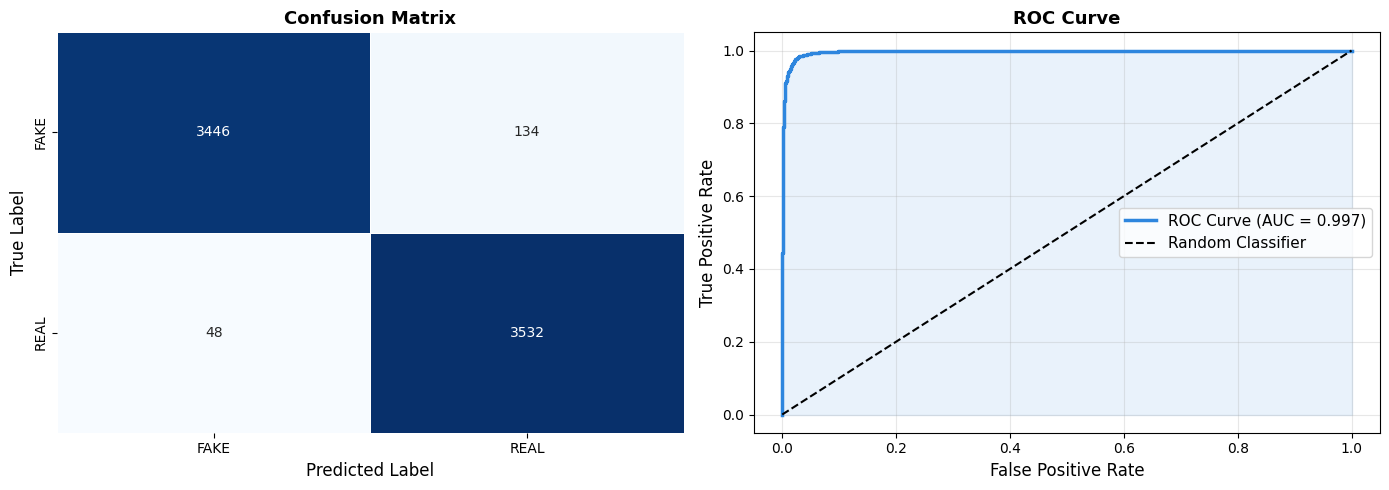

In [ ]:
#Evaluation & Visualization
y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]  # Probability of REAL

print('='*55)
print('           CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_test, y_pred, target_names=['FAKE', 'REAL']))
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_pred_prob):.4f}')

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'],
            linewidths=0.5, cbar=False)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#2E86DE', lw=2.5, label=f'ROC Curve (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2E86DE')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

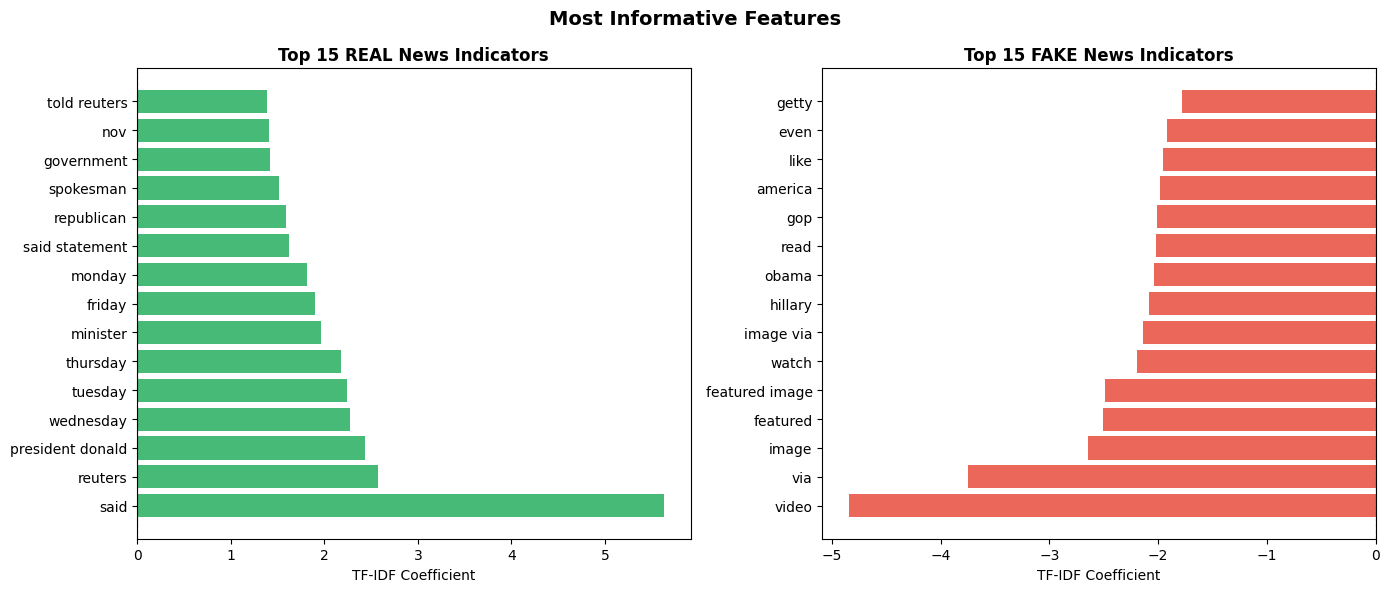

✅ Feature analysis complete!


In [ ]:
#Important Word Analysis
# Extract feature names and coefficients
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coefficients  = pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df = coef_df.sort_values('coefficient', ascending=False)

top_n = 15
top_real = coef_df.head(top_n)  # High coef = strongly REAL
top_fake = coef_df.tail(top_n).sort_values('coefficient')  # Low coef = strongly FAKE

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Real news indicators
axes[0].barh(top_real['feature'], top_real['coefficient'], color='#27AE60', alpha=0.85)
axes[0].set_title(f'Top {top_n} REAL News Indicators', fontsize=12, fontweight='bold')
axes[0].set_xlabel('TF-IDF Coefficient')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')

# Fake news indicators
axes[1].barh(top_fake['feature'], top_fake['coefficient'], color='#E74C3C', alpha=0.85)
axes[1].set_title(f'Top {top_n} FAKE News Indicators', fontsize=12, fontweight='bold')
axes[1].set_xlabel('TF-IDF Coefficient')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Most Informative Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature analysis complete!')

In [ ]:
#Prediction Function
def predict_news(text, pipeline):
    """Predict whether a news article is FAKE or REAL with confidence percentage."""
    cleaned = clean_text(text)
    proba = pipeline.predict_proba([cleaned])[0]
    fake_pct = proba[0] * 100
    real_pct = proba[1] * 100
    verdict = 'REAL' if real_pct > fake_pct else 'FAKE'
    confidence = max(fake_pct, real_pct)
    return {
        'verdict': verdict,
        'confidence': confidence,
        'fake_probability': fake_pct,
        'real_probability': real_pct
    }

# ── Test articles ─────────────────────────────────────────────────────────────
# Each article is written to clearly match its expected category:
#  REAL → neutral tone, named institutions, attributed sources, factual detail
#  FAKE → sensational caps, vague conspiracy, emotional language, no sources
test_articles = [
    {
        'title': 'Test 1 (Expected: REAL)',
        'text': (
            'WASHINGTON (Reuters) - The Federal Reserve raised its benchmark interest rate '
            'by a quarter of a percentage point on Wednesday, the tenth increase in just '
            'over a year, and signaled it may pause further hikes as the economy slows. '
            'Fed Chair Jerome Powell said in a press conference that policymakers would '
            'monitor incoming data closely before deciding on additional tightening. '
            'The decision was unanimous among the Federal Open Market Committee members.'
        )
    },
    {
        'title': 'Test 2 (Expected: FAKE)',
        'text': (
            'SHOCKING TRUTH EXPOSED!! The government has been secretly poisoning the water '
            'supply with mind-control chemicals for DECADES and the mainstream media refuses '
            'to cover it! They do NOT want you to know this! Share before it gets DELETED! '
            'Wake up sheeple — the deep state globalists are behind everything and your '
            'doctors are paid to keep you SICK! The elites are laughing at us! '
            'SPREAD THE TRUTH before the internet censors wipe this out forever!!'
        )
    },
    {
        'title': 'Test 3 (Expected: REAL)',
        'text': (
            'WASHINGTON (Reuters) - The Senate voted 68-32 on Thursday to approve a '
            'bipartisan infrastructure bill allocating 550 billion dollars in new federal '
            'spending on roads, bridges, broadband internet and public transit. '
            'President Biden called the legislation a once-in-a-generation investment. '
            'The bill now moves to the House, where Democratic leaders said they expect '
            'a vote within weeks. Republican Senator Rob Portman, a lead negotiator, '
            'said the package was fully paid for through repurposed federal funds.'
        )
    },
    {
        'title': 'Test 4 (Expected: FAKE)',
        'text': (
            'BREAKING: Whistleblower CONFIRMS that 5G towers were secretly activated '
            'to trigger a new pandemic on purpose! Big Pharma and the Deep State have '
            'been planning this for years — and now the proof is UNDENIABLE! '
            'This video is being BANNED everywhere. Doctors who spoke out have '
            'mysteriously disappeared. Share this NOW before it is too late!! '
            'The globalist agenda is accelerating — WAKE UP before it is too late!'
        )
    },
]

print('='*60)
print('         REAL-TIME PREDICTION TESTS')
print('='*60)

all_correct = True
for item in test_articles:
    result = predict_news(item['text'], pipeline)
    bar_fake = '█' * int(result['fake_probability'] / 5)
    bar_real = '█' * int(result['real_probability'] / 5)
    expected = 'REAL' if 'REAL' in item['title'] else 'FAKE'
    correct  = '✅' if result['verdict'] == expected else '❌'
    if result['verdict'] != expected:
        all_correct = False
    print(f"\n{correct} {item['title']}")
    print(f"   Verdict    : {'🔴 FAKE' if result['verdict'] == 'FAKE' else '🟢 REAL'}")
    print(f"   Confidence : {result['confidence']:.1f}%")
    print(f"   FAKE {bar_fake:<20} {result['fake_probability']:.1f}%")
    print(f"   REAL {bar_real:<20} {result['real_probability']:.1f}%")

print()
if all_correct:
    print('🎉 All predictions correct!')
else:
    print('⚠️  Some predictions were incorrect — check training data or hyperparameters.')

         REAL-TIME PREDICTION TESTS

✅ Test 1 (Expected: REAL)
   Verdict    : 🟢 REAL
   Confidence : 75.1%
   FAKE ████                 24.9%
   REAL ███████████████      75.1%

✅ Test 2 (Expected: FAKE)
   Verdict    : 🔴 FAKE
   Confidence : 80.3%
   FAKE ████████████████     80.3%
   REAL ███                  19.7%

✅ Test 3 (Expected: REAL)
   Verdict    : 🟢 REAL
   Confidence : 87.3%
   FAKE ██                   12.7%
   REAL █████████████████    87.3%

✅ Test 4 (Expected: FAKE)
   Verdict    : 🔴 FAKE
   Confidence : 74.9%
   FAKE ██████████████       74.9%
   REAL █████                25.1%

🎉 All predictions correct!


In [ ]:
#Save Model in pkl
!pip install joblib
import os
import json
import joblib

from sklearn.metrics import roc_auc_score

os.makedirs('model_artifacts', exist_ok=True)

# Save the full pipeline (TF-IDF + LR together)
joblib.dump(pipeline, 'model_artifacts/fake_news_pipeline.pkl')

# Save model metadata
metadata = {
    'model_version': '1.0.0',
    'algorithm': 'TF-IDF + Logistic Regression',
    'train_accuracy': float(f'{train_acc:.4f}'),
    'test_accuracy': float(f'{test_acc:.4f}'),
    'cv_mean': float(f'{cv_scores.mean():.4f}'),
    'cv_std': float(f'{cv_scores.std():.4f}'),
    'roc_auc': float(f'{roc_auc_score(y_test, y_pred_prob):.4f}'),
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
    'tfidf_max_features': 50000,
    'tfidf_ngram_range': [1, 2],
    'lr_C': 1.0,
    'labels': {'0': 'FAKE', '1': 'REAL'}
}

with open('model_artifacts/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ Model artifacts saved to model_artifacts/')
print('Files created:')
for f in os.listdir('model_artifacts'):
    size = os.path.getsize(f'model_artifacts/{f}')
    print(f'  📄 {f}  ({size/1024:.1f} KB)')

print(f'\n📦 Model Summary:')
print(f'   Train Accuracy : {train_acc:.2%}')
print(f'   Test Accuracy  : {test_acc:.2%}')
print(f'   CV Accuracy    : {cv_scores.mean():.2%} ± {cv_scores.std():.2%}')
print(f'   ROC-AUC        : {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'\n🚀 Download model_artifacts/ folder and use in VS Code!')

✅ Model artifacts saved to model_artifacts/
Files created:
  📄 model_metadata.json  (0.4 KB)
  📄 fake_news_pipeline.pkl  (363.0 KB)

📦 Model Summary:
   Train Accuracy : 97.76%
   Test Accuracy  : 97.46%
   CV Accuracy    : 97.26% ± 0.19%
   ROC-AUC        : 0.9968

🚀 Download model_artifacts/ folder and use in VS Code!


In [ ]:
# Download the artifacts as a ZIP
import shutil
shutil.make_archive('fake_news_model', 'zip', 'model_artifacts')

from google.colab import files
files.download('fake_news_model.zip')
print('✅ Downloading fake_news_model.zip — place the contents in your VS Code project!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloading fake_news_model.zip — place the contents in your VS Code project!
